# *Práctica de Laboratorio Nro. 006: Distribuciones Continuas Notables: Modelado Gaussiano, Estandarización y Pruebas de Normalidad*

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
### Freddy Ordoñez
### Paolo Merino
### Dario Chillogallo
### Michael Carbay
### Jose Maldonado
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 28 de mayo de 2026

---

## 1. Introducción
En esta práctica nos enfocaremos en el estudio de las distribuciones continuas, con especial énfasis en el modelado Gaussiano y las pruebas de normalidad Utilizaremos el ecosistema de ciencia de datos en Python para modelar computacionalmente la Función de Densidad de Probabilidad (PDF) y la Función de Distribución Acumulada (CDF) de la distribución Normal mediante el uso de la librería `scipy.stats`. Además, avanzaremos más allá de la inspección visual para demostrar científicamente si un conjunto de datos empíricos proviene realmente de una distribución Gaussiana.
## 2. Objetivos de Aprendizaje
* Modelar computacionalmente la Función de Densidad de Probabilidad (PDF) y la Función de Distribución Acumulada (CDF) de la distribución Normal utilizando `scipy.stats`.
* Aplicar el proceso de estandarización (Z-scores) sobre variables continuas del dataset regional del Proyecto Integrador, calculando la probabilidad de ocurrencia de eventos específicos (ABP).
* Investigar y ejecutar métodos visuales (Gráficos Q-Q) y analíticos (Test de Shapiro-Wilk) para validar matemáticamente el supuesto de normalidad en datos empíricos (ABI).


## **Tarea 1: Modelado Matemático y Visualización de la Curva Normal**
1.	Suponga que el tiempo de respuesta de un servidor local se distribuye normalmente con una media de   
**u = 120 ms**   
y una desviación estándar de  
 **sigma = 15 ms**.  
Escriba el siguiente código para graficar la distribución y sombrear el área que representa:  
 **P(X<= 100)** , es decir, respuestas ultrarrápidas:



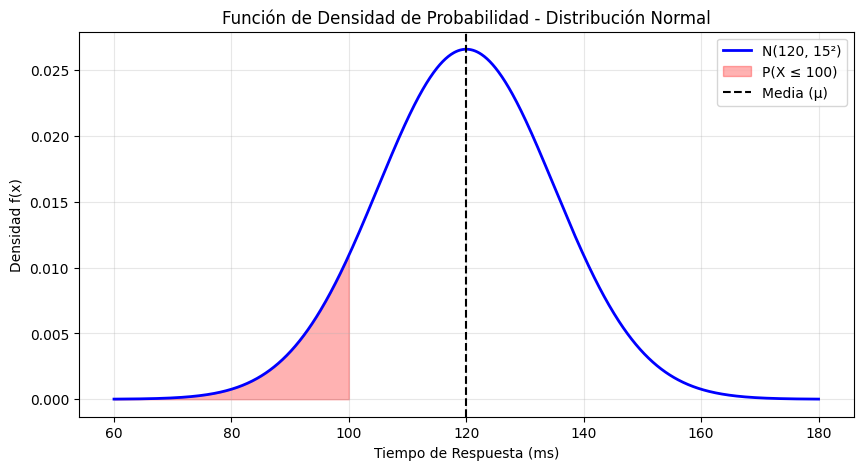

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Parámetros poblacionales
mu = 120
sigma = 15

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Cálculo de la PDF teórica
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)

# Configuración del gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, pdf_normal, 'b-', lw=2, label=f'N({mu}, {sigma}²)')

# Sombreado del área de interés: P(X <= 100)
x_fill = np.linspace(mu - 4*sigma, 100)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='P(X ≤ 100)')

plt.title('Función de Densidad de Probabilidad - Distribución Normal')
plt.xlabel('Tiempo de Respuesta (ms)')
plt.ylabel('Densidad f(x)')
plt.axvline(mu, color='k', linestyle='--', label='Media (μ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")


## **Tarea 2: Estandarización y Cálculo de Valores Z**


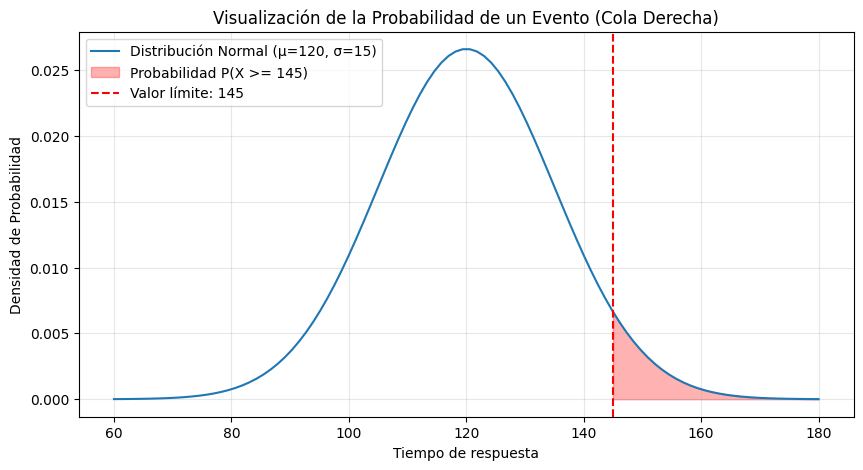

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros
mu = 120
sigma = 15
x_lento = 145

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)

# Crear la gráfica
plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Distribución Normal (μ=120, σ=15)')

# Sombrear el área de interés (P(X >= 145))
x_fill = np.linspace(x_lento, mu + 4*sigma, 100)
y_fill = norm.pdf(x_fill, mu, sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label=f'Probabilidad P(X >= {x_lento})')

# Personalización
plt.axvline(x_lento, color='red', linestyle='--', label=f'Valor límite: {x_lento}')
plt.title('Visualización de la Probabilidad de un Evento (Cola Derecha)')
plt.xlabel('Tiempo de respuesta')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")

## **Tarea 3: Hito del Proyecto - Aplicación Probabilística Regional (ABP)**

**Escenario Problemático:**
Para el análisis de nuestro dataset regional (`enemdu_consumidor_2026_01.csv`), hemos seleccionado una variable de naturaleza continua relacionada con el perfil socioeconómico. Nos interesa evaluar la probabilidad de que esta variable caiga dentro de un rango específico.

**Pregunta de investigación:**
¿Cuál es la probabilidad de que la variable caiga en un rango crítico $[a, b]$ en la región, asumiendo un comportamiento Gaussiano?

Para resolver esto, extraeremos la media muestral ($\bar{x}$) y la desviación estándar muestral ($s$) de los datos empíricos, asumiendo que son estimadores perfectos de $\mu$ y $\sigma$.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'

import pandas as pd
from scipy.stats import norm

# 1. Importar el dataset regional indicando que el separador es punto y coma
df = pd.read_csv(ruta, sep=';')

# === CONFIGURACIÓN ===
# Cambia 'nombre_de_tu_columna' por la variable continua que elijas evaluar [cite: 50]
columna_variable = 'fexp'

# Define tu rango crítico [a, b] [cite: 56, 57]
a = 400.0  # Límite inferior
b = 800.0  # Límite superior
# =====================

# Limpiar los datos eliminando valores nulos para esa columna
# Convertir 'fexp' a numérico, reemplazando la coma por un punto para los decimales
df['fexp'] = df['fexp'].str.replace(',', '.', regex=False).astype(float)
datos_limpios = pd.to_numeric(df[columna_variable], errors='coerce').dropna()

# 2. Extraer media y desviación estándar [cite: 51, 52]
mu = datos_limpios.mean()
sigma = datos_limpios.std()

print("--- 1. PARÁMETROS EMPÍRICOS ---")
print(f"Variable analizada: {columna_variable}")
print(f"Media (\u03bc): {mu:.4f}")
print(f"Desviación Estándar (\u03c3): {sigma:.4f}\n")

# 3. Calcular la probabilidad utilizando scipy.stats.norm.cdf
probabilidad = norm.cdf(b, loc=mu, scale=sigma) - norm.cdf(a, loc=mu, scale=sigma)

print("--- 2. CÁLCULO DE PROBABILIDAD ---")
print(f"P({a} \u2264 X \u2264 {b}) = {probabilidad:.4f}")
print(f"En porcentaje: {probabilidad * 100:.2f}%\n")

# 4. Interpretación para el proyecto
print("--- 3. INTERPRETACIÓN ---")
print(f"Asumiendo que los datos empíricos de '{columna_variable}' siguen una distribución Normal,")
print(f"existe un {probabilidad * 100:.2f}% de probabilidad de que un registro seleccionado")
print(f"al azar caiga dentro del rango crítico definido entre {a} y {b}.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- 1. PARÁMETROS EMPÍRICOS ---
Variable analizada: fexp
Media (μ): 599.3673
Desviación Estándar (σ): 1238.4837

--- 2. CÁLCULO DE PROBABILIDAD ---
P(400.0 ≤ X ≤ 800.0) = 0.1283
En porcentaje: 12.83%

--- 3. INTERPRETACIÓN ---
Asumiendo que los datos empíricos de 'fexp' siguen una distribución Normal,
existe un 12.83% de probabilidad de que un registro seleccionado
al azar caiga dentro del rango crítico definido entre 400.0 y 800.0.


## **Tarea 4: ABI - Validación Matemática del Supuesto de Normalidad**



In [9]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'

df = pd.read_csv(ruta, sep=';')

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   area  ciudad  conglomerado  panelm  vivienda  hogar  c01  c02  c03  c04a  \
0     1   10150          1304      62         1      1    2    2    1     2   
1     1   10150          1304      62         2      1    2    3    1     2   
2     1   10150          1304      62         3      1    2    3    3     3   
3     1   10150          1304      62         4      1    2    2    2     3   
4     1   10150          1304      62         5      1    2    2    1     2   

   ...  c18  c19  c20a  c21a  estrato              fexp          upm  \
0  ...    2    3     2     2     2713  102,542333745242  10150001304   
1  ...    1    2     2     2     2713  102,542333745242  10150001304   
2  ...    3    3     2     2     2713  102,542333745242  10150001304   
3  ...    3    2     2     3     2713  102,542333745242  10150001304   
4  ...    1    2     2     2     271

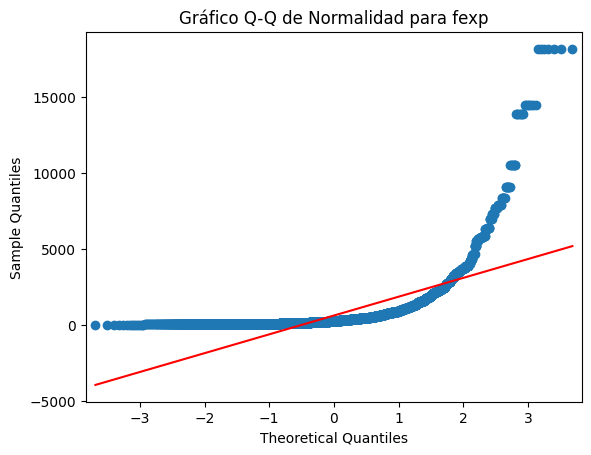

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro

# Convert 'fexp' to numeric, replacing comma with dot for decimals
df['fexp'] = df['fexp'].str.replace(',', '.', regex=False).astype(float)

datos_variable = df['fexp'].dropna()

# 1. Gráfico Q-Q
sm.qqplot(datos_variable, line='s')
plt.title('Gráfico Q-Q de Normalidad para fexp')
plt.show()

In [ ]:
# 2. Test de Shapiro-Wilk
stat, p_value = shapiro(datos_variable)
print(f"Estadístico de Shapiro: {stat:.4f}, p-valor: {p_value:.4e}")

alpha = 0.05 # Nivel de significancia

if p_value > alpha:
    print("No se rechaza la hipótesis nula (H0). La variable 'fexp' sigue una distribución normal.")
else:
    print("Se rechaza la hipótesis nula (H0). La variable 'fexp' no sigue una distribución normal.")

Estadístico de Shapiro: 0.4250, p-valor: 1.2608e-97
Se rechaza la hipótesis nula (H0). La variable 'fexp' no sigue una distribución normal.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8791.
  res = hypotest_fun_out(*samples, **kwds)


### Justificación de la No Normalidad de la Variable `fexp`

Basándonos en el análisis gráfico (Q-Q Plot) y el análisis analítico (Test de Shapiro-Wilk) realizados para la variable `fexp`, podemos concluir que esta **no sigue una distribución normal**.

1.  **Observación del Gráfico Cuantil-Cuantil (Q-Q Plot)**:
    *   El Q-Q Plot muestra claramente que los puntos de los datos de `fexp` **no siguen la línea diagonal de 45 grados**. En lugar de ello, se observa una desviación significativa de la línea, especialmente en los extremos (colas), lo que es un indicador visual fuerte de que la distribución de `fexp` no es normal. Si fuera normal, los puntos se alinearían muy cerca de esta diagonal.

2.  **Resultado del Test de Shapiro-Wilk**:
    *   El test de Shapiro-Wilk es una prueba estadística formal para la normalidad. La hipótesis nula (H0) de este test es que los datos provienen de una distribución normal.
    *   El resultado obtenido fue:
        *   Estadístico de Shapiro: `0.4250`
        *   p-valor: `1.2608e-97`
    *   Utilizando un nivel de significancia (alpha) común de `0.05`, observamos que el `p-valor` (1.2608e-97) es **mucho menor que alpha** (0.05). Cuando el p-valor es menor que alpha, **se rechaza la hipótesis nula**.
    *   Por lo tanto, el test de Shapiro-Wilk confirma estadísticamente que la variable `fexp` **no sigue una distribución normal**.

    *Nota: Aunque se recibió una advertencia de que el p-valor puede no ser preciso para N > 5000 (en este caso N=8791), la magnitud extremadamente pequeña del p-valor en combinación con la clara desviación en el Q-Q Plot, refuerzan firmemente la conclusión de no normalidad.*

---

#**Preguntas de Control**

---

## Preguntas de Control

**1. Matemáticamente, ¿por qué en una variable aleatoria continua modelada por una función de densidad $f(x)$, la probabilidad de que tome un valor exacto es cero, es decir, $P(X = c) = 0$?**

En las variables continuas, la probabilidad se calcula como el área bajo la curva de su función de densidad $f(x)$ a lo largo de un intervalo. Matemáticamente, esto se obtiene mediante una integral definida. Si intentamos calcular la probabilidad de un punto exacto $c$, los límites inferior y superior de la integral son exactamente los mismos. Un área sin anchura es igual a cero:$$P(X = c) = \int_{c}^{c} f(x) dx = 0$$
Por lo tanto, en variables continuas solo tiene sentido calcular probabilidades en rangos (ej. mayor que, menor que, o entre dos valores).

---

**2. Interprete conceptualmente qué significa que un valor de su dataset regional tenga un puntaje estándar de $Z = -2.45$. ¿Se consideraría un valor atípico bajo el criterio de la regla empírica?**

Un valor de $Z = -2.45$ significa que ese dato en particular se encuentra a 2.45 desviaciones estándar por debajo (a la izquierda) de la media del dataset de Loja.
Según la regla empírica (o regla del 68-95-99.7), aproximadamente el 95% de los datos en una distribución normal caen dentro del rango de $-2$ y $+2$ desviaciones estándar. Dado que -2.45 supera este límite, cae en la "cola" extrema de la distribución, por lo que sí se consideraría un valor atípico o inusual.*

---

**3. En la Tarea 3, calculó probabilidades asumiendo que su variable regional seguía una distribución Normal. ¿Qué riesgo metodológico existe al tomar decisiones basadas en este cálculo si la gráfica de la variable presenta un fuerte sesgo (skewness)?**

Cuando se calcula probabilidades asumiendo una distribución Normal para una variable que en realidad presenta un fuerte sesgo (skewness), se incurre en varios riesgos metodológicos significativos:

1.  **Estimaciones de probabilidad inexactas:** La distribución Normal es simétrica. Si la variable está sesgada (por ejemplo, tiene una cola larga a la derecha o a la izquierda), los valores de la media y la desviación estándar calculados sobre esta distribución sesgada no representarán adecuadamente los parámetros de una distribución Normal que pudiera aproximarla. Esto lleva a que las probabilidades calculadas (como las de la Tarea 3) sean incorrectas. Por ejemplo, si un sesgo positivo (cola a la derecha), la probabilidad de eventos en la cola superior podría subestimarse y en la cola inferior sobreestimarse, o viceversa.

2.  **Modelado inapropiado de la realidad:** La distribución Normal asume que la mayoría de los datos se agrupan alrededor de la media de manera simétrica, y que los valores extremos son igualmente probables en ambas direcciones. Un sesgo indica que esto no es así, lo que significa que el modelo Normal no está capturando la verdadera forma o comportamiento de los datos. Esto puede llevar a conclusiones erróneas sobre el fenómeno que se está estudiando.

3.  **Decisiones erróneas:** Si las probabilidades calculadas son incorrectas, cualquier decisión basada en ellas será inherentemente defectuosa. Por ejemplo, si se está evaluando el riesgo de un evento extremo (como en el caso de la Tarea 3, un rango crítico), y el modelo Normal subestima o sobreestima esa probabilidad debido al sesgo, las estrategias o políticas implementadas podrían no ser efectivas o incluso contraproducentes.

4.  **Invalidez de inferencias estadísticas:** Muchas pruebas estadísticas y modelos de regresión asumen normalidad en los errores o en las variables. Si esta suposición se viola gravemente debido a un sesgo, las inferencias obtenidas (intervalos de confianza, p-valores, etc.) pueden no ser válidas, lo que afectaría la fiabilidad de las conclusiones científicas o de ingeniería.

En resumen, el riesgo principal es que, al forzar un modelo Normal sobre datos sesgados, estamos construyendo una representación simplificada y distorsionada de la realidad, lo que conduce a predicciones y decisiones poco fiables o incorrectas.

---

**4. Con base en la Tarea 4 (ABI), si el p-valor del test de Shapiro-Wilk es $0.001$, ¿cuál es la conclusión estadística respecto a la distribución de sus datos regionales? ¿Se invalida el cálculo realizado en la Tarea 3?**

Basado en un p-valor de 0.001 del test de Shapiro-Wilk, y considerando un nivel de significancia (alpha) estándar de 0.05, la conclusión es la siguiente:

*   **Conclusión Estadística:** El test de Shapiro-Wilk tiene como hipótesis nula (H0) que los datos siguen una distribución normal. Dado que el p-valor (0.001) es mucho menor que el nivel de significancia (0.05), se **rechaza la hipótesis nula**. Esto significa que hay evidencia estadística fuerte para concluir que la distribución de sus datos regionales **NO es normal**.

*   **Invalidación del Cálculo en la Tarea 3:** Sí, el cálculo realizado en la Tarea 3 **se invalida metodológicamente** al no cumplirse el supuesto de normalidad. En la Tarea 3, se calculó la probabilidad asumiendo un comportamiento Gaussiano de la variable 'fexp'. Si el test de Shapiro-Wilk indica que la variable no sigue una distribución normal, entonces el modelo Gaussiano utilizado no es una representación adecuada de los datos. Esto significa que las probabilidades obtenidas en la Tarea 3, basadas en esa suposición errónea, no son fiables ni válidas para describir la realidad de los datos.

---

**5. Explique el principio matemático detrás del Gráfico Q-Q. ¿Qué representan los cuantiles teóricos en el eje X versus los cuantiles empíricos en el eje Y?**

El Gráfico Q-Q (Cuantil-Cuantil) es una herramienta gráfica utilizada para comparar la distribución de un conjunto de datos con una distribución teórica (a menudo la Normal). Su principio matemático se basa en la comparación de los cuantiles de ambas distribuciones.

**Principio Matemático:**

1.  **Ordenación de Datos:** Los datos empíricos (su variable regional) se ordenan de menor a mayor.
2.  **Cálculo de Cuantiles Empíricos:** Para cada punto de dato ordenado, se calcula su posición en la distribución empírica. Si tenemos `n` datos, el i-ésimo dato ordenado representa el cuantil `(i - 0.5) / n` de la distribución empírica.
3.  **Cálculo de Cuantiles Teóricos:** Se calcula el valor que un cuantil equivalente tendría en la distribución teórica de referencia (por ejemplo, una distribución Normal con la media y desviación estándar de sus datos). Es decir, para cada cuantil empírico `p`, se busca el valor `x` tal que `P(X <= x) = p` en la distribución teórica.
4.  **Graficación:** Se traza un gráfico donde cada punto corresponde a un par `(Cuantil Teórico, Cuantil Empírico)`.
5.  **Línea de Referencia:** Se añade una línea de 45 grados (y=x) que representa la situación ideal donde los cuantiles empíricos y teóricos son idénticos.

**¿Qué representan los cuantiles teóricos en el eje X versus los cuantiles empíricos en el eje Y?**

*   **Eje X (Cuantiles Teóricos):** Representa los valores que se esperarían de una distribución si los datos realmente provinieran de la distribución teórica (la Normal en este caso). Por ejemplo, si se está comparando con una distribución Normal estándar, el eje X mostraría los valores Z correspondientes a ciertos percentiles.

*   **Eje Y (Cuantiles Empíricos):** Representa los valores reales observados en sus datos ordenados. Estos son los cuantiles de la distribución empírica de su variable.

**Interpretación:**
Si los puntos del gráfico Q-Q se alinean aproximadamente a lo largo de la línea de 45 grados, esto sugiere que la distribución de los datos empíricos es similar a la distribución teórica. Desviaciones de esta línea, como curvaturas o colas pesadas, indican diferencias significativas en la forma de las distribuciones, lo que sugiere que los datos no siguen la distribución teórica.